In [1]:
from torchvision import datasets
from torchvision.transforms import ToTensor


In [2]:
training_data = datasets.EuroSAT(
    root="/content/data",
    download=True,
    transform=ToTensor()
)


100%|██████████| 94.3M/94.3M [00:01<00:00, 70.4MB/s]


In [3]:
from torch.utils.data import random_split
train_size = int(0.8 * len(training_data))
val_size =len(training_data) - train_size

In [4]:
import torch
train_dataset, val_dataset = random_split(
    training_data,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

In [5]:
from torch.utils.data import DataLoader, Subset, random_split
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [6]:
from torchvision import transforms

# Пайплайн для тренировки (с аугментациями)
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)), # Приводим к единому размеру
    transforms.RandomHorizontalFlip(p=0.5), # Отражение с вероятностью 50%
    transforms.RandomRotation(15), # Поворот на угол от -15 до 15 градусов
    transforms.ColorJitter(
        brightness=0.2, # Изменение яркости (до 20%)
        contrast=0.2    # Изменение контраста (до 20%)
    ),
    transforms.ToTensor(), # В тензор [0, 1]
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
# Пайплайн для валидации (БЕЗ аугментаций)
val_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
import torch
import torch.nn as nn
from torchsummary import summary

class SimpleNet(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleNet, self).__init__()

        #64x64 -> 32x32
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        #32x32 -> 16x16
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        #16x16 -> 8x8
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        #8x8 -> 4x4
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )


        # 64 / (2^4) = 4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x

# Инициализация и сводка
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleNet(num_classes=10).to(device)

# Вывод параметров (вход 3 канала, 64x64)
summary(model, (3, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 64, 64]             896
       BatchNorm2d-2           [-1, 32, 64, 64]              64
              ReLU-3           [-1, 32, 64, 64]               0
         MaxPool2d-4           [-1, 32, 32, 32]               0
            Conv2d-5           [-1, 64, 32, 32]          18,496
       BatchNorm2d-6           [-1, 64, 32, 32]             128
              ReLU-7           [-1, 64, 32, 32]               0
         MaxPool2d-8           [-1, 64, 16, 16]               0
            Conv2d-9          [-1, 128, 16, 16]          73,856
      BatchNorm2d-10          [-1, 128, 16, 16]             256
             ReLU-11          [-1, 128, 16, 16]               0
        MaxPool2d-12            [-1, 128, 8, 8]               0
           Conv2d-13            [-1, 256, 8, 8]         295,168
      BatchNorm2d-14            [-1, 25

Epoch 1/20: 100%|██████████| 675/675 [04:51<00:00,  2.32it/s, loss=0.713]


Validation Accuracy: 50.50%


Epoch 2/20: 100%|██████████| 675/675 [05:09<00:00,  2.18it/s, loss=0.756]


Validation Accuracy: 77.41%


Epoch 3/20: 100%|██████████| 675/675 [05:23<00:00,  2.09it/s, loss=0.515]


...

Validation Accuracy: 95.17%


Epoch 19/20: 100%|██████████| 675/675 [05:20<00:00,  2.11it/s, loss=0.211]


Validation Accuracy: 95.04%


Epoch 20/20: 100%|██████████| 675/675 [05:15<00:00,  2.14it/s, loss=0.13]


Validation Accuracy: 95.20%


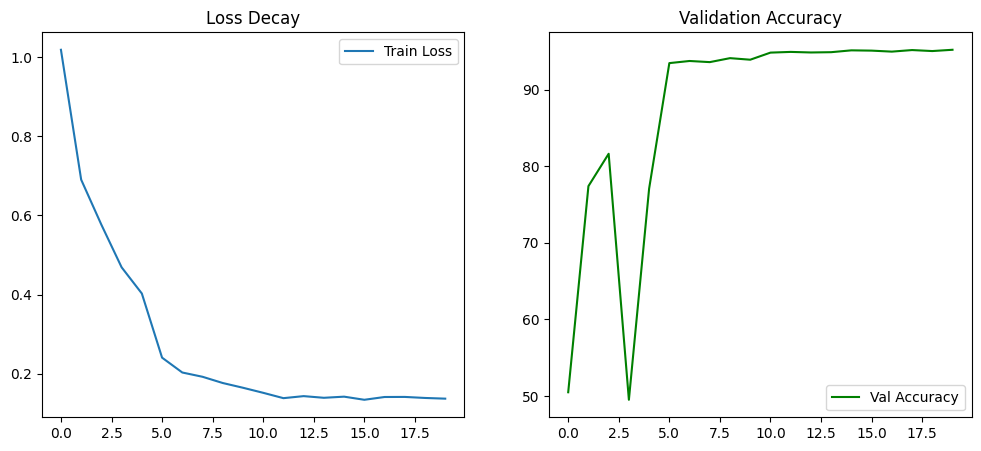

In [9]:
import torch.optim as optim
from torch.optim import lr_scheduler
import matplotlib.pyplot as plt
from tqdm import tqdm


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

train_losses, val_accs = [], []


num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    train_losses.append(running_loss / len(train_loader))

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    val_accs.append(acc)
    print(f"Validation Accuracy: {acc:.2f}%")


    scheduler.step()


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Loss Decay')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accs, label='Val Accuracy', color='green')
plt.title('Validation Accuracy')
plt.legend()
plt.show()

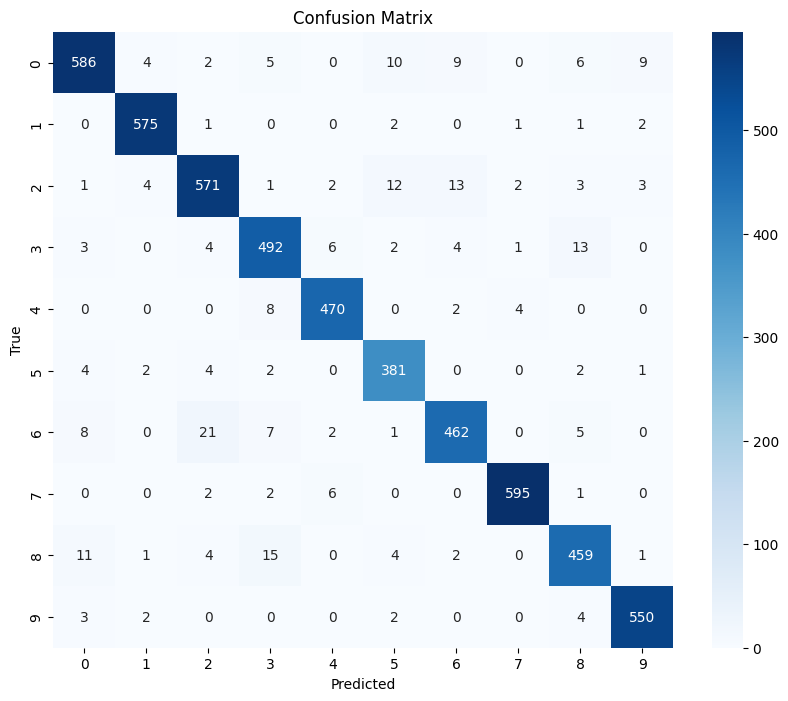

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

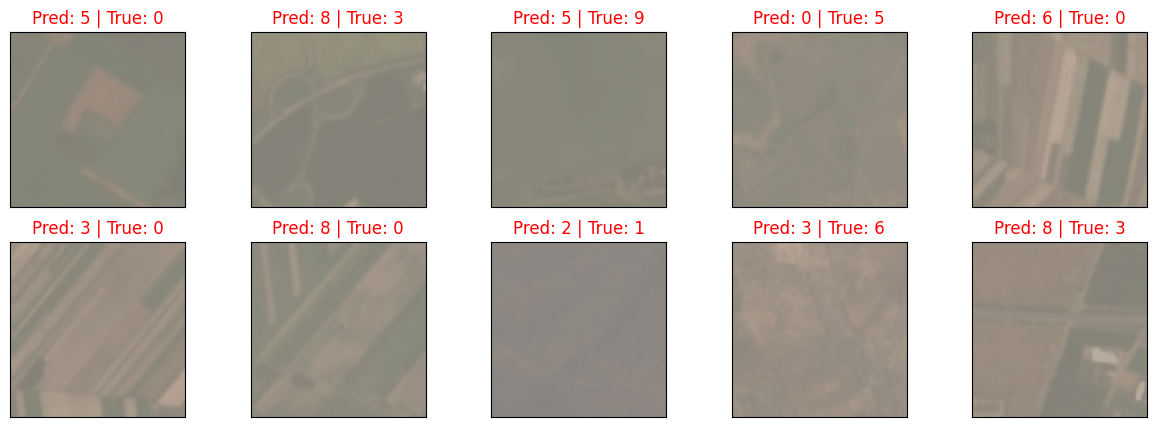

In [12]:
def plot_errors(model, dataloader, num_images=10):
    model.eval()
    errors = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # Ищем несовпадения
            incorrect_idx = (preds != labels).nonzero(as_tuple=True)[0]
            for idx in incorrect_idx:
                if len(errors) < num_images:
                    errors.append((inputs[idx].cpu(), preds[idx].item(), labels[idx].item()))
                else:
                    break
            if len(errors) >= num_images: break

    # Отрисовка
    fig = plt.figure(figsize=(15, 5))
    for i, (img, pred, gold) in enumerate(errors):
        img = img.permute(1, 2, 0) # C,H,W -> H,W,C
        # Денормализация для корректного вывода (ImageNet stats)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img.numpy() + mean
        img = np.clip(img, 0, 1)

        ax = fig.add_subplot(2, 5, i+1, xticks=[], yticks=[])
        ax.imshow(img)
        ax.set_title(f"Pred: {pred} | True: {gold}", color="red")
    plt.show()

plot_errors(model, val_loader)

In [13]:
# Сохраняем веса
torch.save(model.state_dict(), 'simple_net_v1.pth')



In [14]:
torch.save(model, 'full_model.pth')

Предсказание: SeaLake


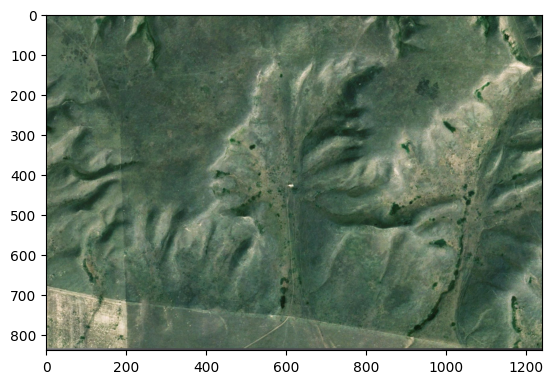

In [16]:
from PIL import Image

def predict_external_image(img_path, model, transform, classes):
    img = Image.open(img_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device) # Добавляем Batch Dimension

    model.eval()
    with torch.no_grad():
        output = model(img_t)
        _, pred = torch.max(output, 1)

    print(f"Предсказание: {classes[pred.item()]}")
    plt.imshow(img)
    plt.show()

# Использование:
class_names = training_data.classes # Define class_names here
predict_external_image('/content/Micro-Macro-iphones-ru-11.jpg', model, val_transforms, class_names)